# Algoritmos de Compresión

Guía completa sobre cómo funcionan los algoritmos que reducen el tamaño de los datos.

## ¿Qué es la compresión de datos?

La **compresión de datos** consiste en representar información usando **menos bits** que la representación original.

### Tipos de compresión

| Tipo | Descripción | Aplicaciones |
|------|-------------|--------------|
| **Sin pérdida** (*Lossless*) | Se recupera el 100% de los datos originales | ZIP, PNG, FLAC, texto |
| **Con pérdida** (*Lossy*) | Se pierde información irrelevante | JPEG, MP3, MP4, streaming |

### Métricas clave

**Ratio de compresión:**

$$R = \frac{\text{Tamaño original}}{\text{Tamaño comprimido}}$$

**Porcentaje de ahorro:**

$$\text{Ahorro} = \left(1 - \frac{\text{Tamaño comprimido}}{\text{Tamaño original}}\right) \times 100\%$$

### Teoría de la información — Entropía de Shannon

La **entropía** $H$ de una fuente es el límite teórico mínimo de bits por símbolo:

$$H = -\sum_{i=1}^{n} p_i \log_2 p_i$$

donde $p_i$ es la probabilidad del símbolo $i$.

> **Ningún algoritmo sin pérdida puede comprimir por debajo de la entropía.**

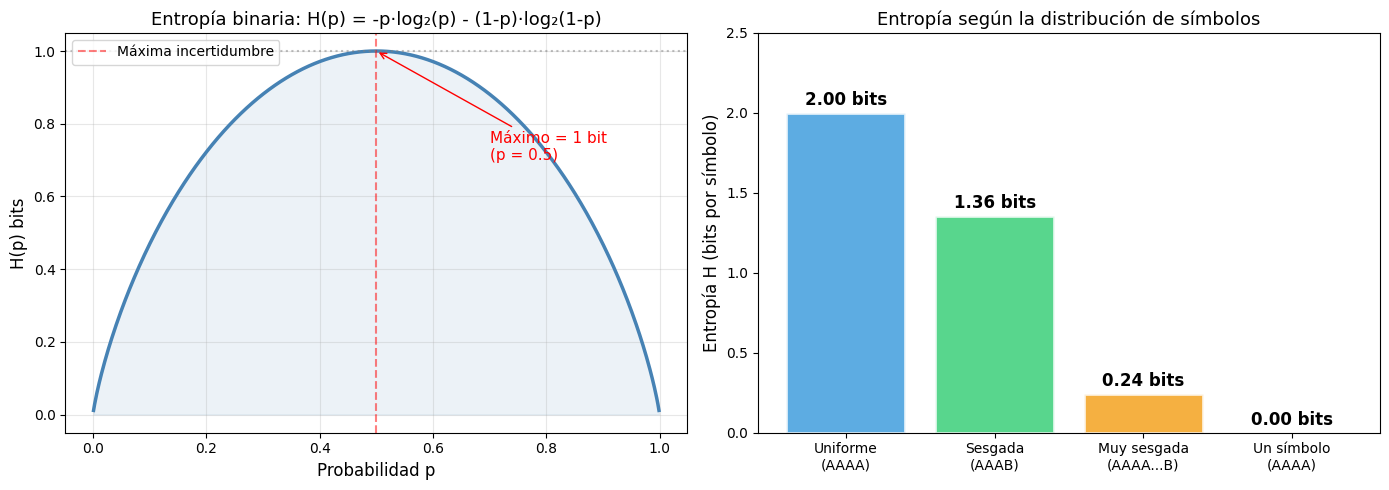

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Entropy visualization
# Binary entropy function H(p) = -p*log2(p) - (1-p)*log2(1-p)
p = np.linspace(0.001, 0.999, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary entropy
axes[0].plot(p, H, 'steelblue', linewidth=2.5)
axes[0].fill_between(p, H, alpha=0.1, color='steelblue')
axes[0].set_xlabel('Probabilidad p', fontsize=12)
axes[0].set_ylabel('H(p) bits', fontsize=12)
axes[0].set_title('Entropía binaria: H(p) = -p·log₂(p) - (1-p)·log₂(1-p)', fontsize=13)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Máxima incertidumbre')
axes[0].axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
axes[0].annotate('Máximo = 1 bit\n(p = 0.5)', xy=(0.5, 1.0), xytext=(0.7, 0.7),
                fontsize=11, arrowprops=dict(arrowstyle='->', color='red'), color='red')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Entropy for different distributions
labels = ['Uniforme\n(AAAA)', 'Sesgada\n(AAAB)', 'Muy sesgada\n(AAAA...B)', 'Un símbolo\n(AAAA)']
# 4 symbols uniform: H = 2, skewed: varies
distributions = [
    [0.25, 0.25, 0.25, 0.25],  # uniform
    [0.7, 0.1, 0.1, 0.1],      # skewed
    [0.97, 0.01, 0.01, 0.01],  # very skewed
    [1.0, 0.0, 0.0, 0.0],      # deterministic
]
entropies = []
for dist in distributions:
    h = 0
    for pi in dist:
        if pi > 0:
            h -= pi * np.log2(pi)
    entropies.append(h)

bars = axes[1].bar(range(4), entropies, color=['#3498DB', '#2ECC71', '#F39C12', '#E74C3C'], alpha=0.8, edgecolor='white', linewidth=2)
for i, (bar, h) in enumerate(zip(bars, entropies)):
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.2f} bits', ha='center', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylabel('Entropía H (bits por símbolo)', fontsize=12)
axes[1].set_title('Entropía según la distribución de símbolos', fontsize=13)
axes[1].set_ylim(0, 2.5)

plt.tight_layout()
plt.show()

## Run-Length Encoding (RLE)

### ¿Cómo funciona?

RLE reemplaza **secuencias consecutivas** del mismo símbolo por el par (símbolo, cantidad).

### Pseudocódigo

```
función RLE_Comprimir(texto):
    resultado = []
    i = 0
    mientras i < longitud(texto):
        símbolo = texto[i]
        cuenta = 1
        mientras i + cuenta < longitud(texto) y texto[i + cuenta] == símbolo:
            cuenta += 1
        resultado.agregar( (símbolo, cuenta) )
        i += cuenta
    retornar resultado
```

### Complejidad

| Operación | Tiempo | Espacio |
|-----------|--------|---------|
| Comprimir | $O(n)$ | $O(n)$ |
| Descomprimir | $O(n)$ | $O(n)$ |

### Cuándo es efectivo

- **Muy efectivo**: imágenes con áreas de color sólido, datos con muchas repeticiones
- **Inefectivo**: texto natural, datos aleatorios (puede incluso *expandir* los datos)

### Ejemplo paso a paso

**Entrada**: `AAABBBCCCCDDDDDDEEEF`

| Paso | Secuencia | Codificación |
|------|-----------|-------------|
| 1 | `AAA` | `A3` |
| 2 | `BBB` | `B3` |
| 3 | `CCCC` | `C4` |
| 4 | `DDDDDD` | `D6` |
| 5 | `EEE` | `E3` |
| 6 | `F` | `F1` |

**Resultado**: `A3B3C4D6E3F1`

- **Original**: 20 caracteres
- **Comprimido**: 12 caracteres (6 pares)
- **Ratio**: $20/12 = 1.67$
- **Ahorro**: $40\%$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def rle_encode(text):
    '''RLE compression with step-by-step trace'''
    if not text:
        return [], []
    steps = []
    encoded = []
    i = 0
    while i < len(text):
        char = text[i]
        count = 1
        while i + count < len(text) and text[i + count] == char:
            count += 1
        encoded.append((char, count))
        steps.append({
            'start': i, 'end': i + count - 1,
            'char': char, 'count': count,
            'run': text[i:i+count],
            'code': f'{char}{count}'
        })
        i += count
    return encoded, steps

def rle_decode(encoded):
    return ''.join(char * count for char, count in encoded)

# Demo
text = "AAABBBCCCCDDDDDDEEEF"
encoded, steps = rle_encode(text)
decoded = rle_decode(encoded)

print(f"Original:     '{text}' ({len(text)} chars)")
print(f"Codificado:   {encoded}")
print(f"Como string:  '{''.join(f'{c}{n}' for c,n in encoded)}' ({sum(2 for _ in encoded)} chars)")
print(f"Decodificado: '{decoded}'")
print(f"¿Correcto?    {decoded == text}")
print(f"\nRatio: {len(text)}/{2*len(encoded)} = {len(text)/(2*len(encoded)):.2f}")
print(f"Ahorro: {(1 - 2*len(encoded)/len(text))*100:.1f}%")
print()
print("Pasos:")
for i, step in enumerate(steps):
    print(f"  {i+1}. Posición [{step['start']}-{step['end']}]: '{step['run']}' → {step['code']}")

Original:     'AAABBBCCCCDDDDDDEEEF' (20 chars)
Codificado:   [('A', 3), ('B', 3), ('C', 4), ('D', 6), ('E', 3), ('F', 1)]
Como string:  'A3B3C4D6E3F1' (12 chars)
Decodificado: 'AAABBBCCCCDDDDDDEEEF'
¿Correcto?    True

Ratio: 20/12 = 1.67
Ahorro: 40.0%

Pasos:
  1. Posición [0-2]: 'AAA' → A3
  2. Posición [3-5]: 'BBB' → B3
  3. Posición [6-9]: 'CCCC' → C4
  4. Posición [10-15]: 'DDDDDD' → D6
  5. Posición [16-18]: 'EEE' → E3
  6. Posición [19-19]: 'F' → F1


### Animación: Compresión RLE paso a paso

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

text = "AAABBBCCCCDDDDDDEEEF"
encoded, steps = rle_encode(text)

# Build animation frames
frames = []
# Initial frame
frames.append({'highlighted': set(), 'current_run': '', 'encoded_so_far': '', 'step_msg': 'Inicio', 'active_range': None})
for step in steps:
    rng = set(range(step['start'], step['end'] + 1))
    enc_so_far = ''.join(s['code'] for s in steps[:steps.index(step)+1])
    frames.append({
        'highlighted': rng, 'current_run': step['run'],
        'encoded_so_far': enc_so_far, 'step_msg': f"Run: '{step['run']}' → {step['code']}",
        'active_range': (step['start'], step['end'])
    })

fig, ax = plt.subplots(figsize=(14, 5))

def init():
    ax.clear()
    return []

def update(frame_idx):
    ax.clear()
    f = frames[frame_idx]
    n = len(text)

    # Draw original text characters
    for i, ch in enumerate(text):
        if i in f['highlighted']:
            color = '#FFA500'
            fontweight = 'bold'
        elif any(i in frames[j]['highlighted'] for j in range(frame_idx)):
            color = '#2ECC71'
            fontweight = 'normal'
        else:
            color = 'steelblue'
            fontweight = 'normal'

        ax.add_patch(plt.Rectangle((i, 2), 0.9, 0.9, facecolor=color, edgecolor='white', linewidth=2, alpha=0.8))
        ax.text(i + 0.45, 2.45, ch, ha='center', va='center', fontsize=14, fontweight=fontweight, color='white')
        ax.text(i + 0.45, 1.6, str(i), ha='center', va='center', fontsize=8, color='gray')

    # Draw encoded result
    enc_str = f['encoded_so_far']
    for i, ch in enumerate(enc_str):
        color = '#2ECC71' if i < len(enc_str) - 2 else '#FFA500'
        ax.add_patch(plt.Rectangle((i, 0), 0.9, 0.9, facecolor=color, edgecolor='white', linewidth=2, alpha=0.8))
        ax.text(i + 0.45, 0.45, ch, ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # Labels
    ax.text(-0.5, 2.45, 'Original:', ha='right', va='center', fontsize=12, fontweight='bold')
    ax.text(-0.5, 0.45, 'RLE:', ha='right', va='center', fontsize=12, fontweight='bold')

    # Status
    ax.text(n/2, 3.5, f['step_msg'], ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    if enc_str:
        orig_len = len(text)
        comp_len = len(enc_str)
        ratio_text = f'Original: {orig_len} chars | Comprimido: {comp_len} chars | Ratio: {orig_len/comp_len:.2f}x'
        ax.text(n/2, -0.8, ratio_text, ha='center', fontsize=11, color='gray')

    ax.set_xlim(-2, n + 1)
    ax.set_ylim(-1.5, 4.2)
    ax.axis('off')
    ax.set_title('Run-Length Encoding (RLE)', fontsize=15, fontweight='bold')
    return []

anim = FuncAnimation(fig, update, init_func=init, frames=len(frames), interval=1200, blit=False)
plt.close()
HTML(anim.to_jshtml())

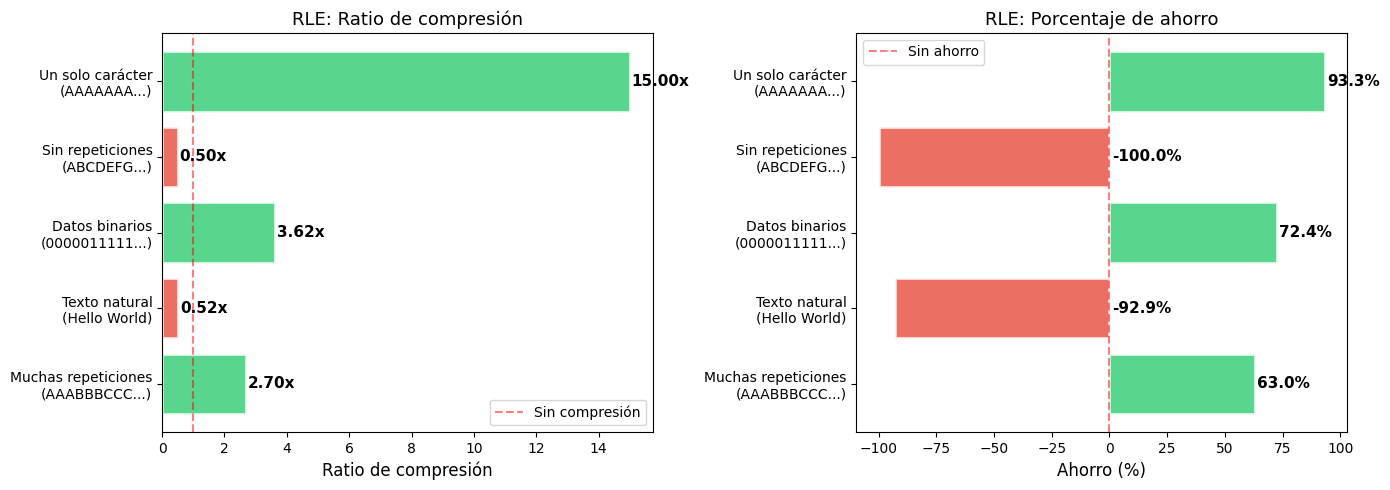

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# RLE effectiveness on different data
test_cases = {
    'Muchas repeticiones\n(AAABBBCCC...)': 'AAAAAABBBBBCCCCCDDDDDEEEEEE',
    'Texto natural\n(Hello World)': 'Hello World, this is a test!',
    'Datos binarios\n(0000011111...)': '00000000001111111110000000011',
    'Sin repeticiones\n(ABCDEFG...)': 'ABCDEFGHIJKLMNOPQRSTUVWXYZ',
    'Un solo carácter\n(AAAAAAA...)': 'A' * 30,
}

labels = []
ratios = []
savings = []

for name, data in test_cases.items():
    enc, _ = rle_encode(data)
    comp_size = 2 * len(enc)  # symbol + count
    orig_size = len(data)
    ratio = orig_size / comp_size if comp_size > 0 else float('inf')
    saving = (1 - comp_size / orig_size) * 100
    labels.append(name)
    ratios.append(ratio)
    savings.append(saving)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ECC71' if s > 0 else '#E74C3C' for s in savings]

axes[0].barh(range(len(labels)), ratios, color=colors, edgecolor='white', linewidth=2, alpha=0.8)
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_xlabel('Ratio de compresión', fontsize=12)
axes[0].set_title('RLE: Ratio de compresión', fontsize=13)
axes[0].axvline(x=1, color='red', linestyle='--', alpha=0.5, label='Sin compresión')
axes[0].legend()

axes[1].barh(range(len(labels)), savings, color=colors, edgecolor='white', linewidth=2, alpha=0.8)
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels, fontsize=10)
axes[1].set_xlabel('Ahorro (%)', fontsize=12)
axes[1].set_title('RLE: Porcentaje de ahorro', fontsize=13)
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Sin ahorro')
axes[1].legend()

for i, (r, s) in enumerate(zip(ratios, savings)):
    axes[0].text(r + 0.05, i, f'{r:.2f}x', va='center', fontsize=11, fontweight='bold')
    axes[1].text(max(s + 1, 1), i, f'{s:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Codificación de Huffman

### ¿Cómo funciona?

Huffman asigna códigos binarios de **longitud variable** a cada símbolo: los más frecuentes reciben códigos más cortos.

### Algoritmo

```
función Huffman(frecuencias):
    1. Crear un nodo hoja por cada símbolo con su frecuencia
    2. Insertar todos los nodos en una cola de prioridad (min-heap)
    3. Mientras haya más de un nodo:
        a. Extraer los 2 nodos con menor frecuencia
        b. Crear un nuevo nodo padre con:
           - frecuencia = suma de los hijos
           - hijo izquierdo = primer nodo (rama 0)
           - hijo derecho = segundo nodo (rama 1)
        c. Insertar el nodo padre en la cola
    4. El nodo restante es la raíz del árbol
    5. Recorrer el árbol para asignar códigos binarios
```

### Propiedades

- **Código prefijo**: ningún código es prefijo de otro → decodificación sin ambigüedad
- **Óptimo**: para codificación símbolo-a-símbolo, Huffman es óptimo
- **Longitud promedio**: se acerca a la entropía $H$

$$H \leq L_{avg} < H + 1$$

### Complejidad

| Operación | Tiempo | Espacio |
|-----------|--------|---------|
| Construir árbol | $O(n \log n)$ | $O(n)$ |
| Codificar | $O(m)$ | $O(n)$ |
| Decodificar | $O(m)$ | $O(n)$ |

donde $n$ = número de símbolos distintos, $m$ = longitud del mensaje.

### Ejemplo paso a paso

**Texto**: `ABRACADABRA`

**Paso 1**: Contar frecuencias

| Símbolo | Frecuencia | Probabilidad |
|---------|------------|-------------|
| A | 5 | 5/11 = 0.454 |
| B | 2 | 2/11 = 0.182 |
| R | 2 | 2/11 = 0.182 |
| C | 1 | 1/11 = 0.091 |
| D | 1 | 1/11 = 0.091 |

**Entropía teórica:**

$$H = -\frac{5}{11}\log_2\frac{5}{11} - 2 \cdot \frac{2}{11}\log_2\frac{2}{11} - 2 \cdot \frac{1}{11}\log_2\frac{1}{11} \approx 2.04 \text{ bits/símbolo}$$

**Paso 2**: Construir el árbol (uniendo los de menor frecuencia)

```
Iteración 1: Unir C(1) + D(1) = CD(2)
Iteración 2: Unir B(2) + R(2) = BR(4)
Iteración 3: Unir CD(2) + BR(4) = CDBR(6)    (o CD(2) + A(5) depende del orden)
...
```

**Paso 3**: Asignar códigos recorriendo el árbol (izquierda=0, derecha=1)

| Símbolo | Código Huffman | Bits |
|---------|---------------|------|
| A | `0` | 1 |
| B | `10` | 2 |
| R | `110` | 3 |
| C | `1110` | 4 |
| D | `1111` | 4 |

**Codificación:**

`ABRACADABRA` → `0 10 110 0 1110 0 1111 0 10 110 0`

- **Original (ASCII)**: $11 \times 8 = 88$ bits
- **Huffman**: $1+2+3+1+4+1+4+1+2+3+1 = 23$ bits
- **Ratio**: $88/23 = 3.83$

In [5]:
import heapq
from collections import Counter

class HuffmanNode:
    def __init__(self, char=None, freq=0, left=None, right=None):
        self.char = char
        self.freq = freq
        self.left = left
        self.right = right

    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(text):
    '''Build Huffman tree and return root + construction steps'''
    freq = Counter(text)
    steps = []

    # Create initial heap
    heap = [HuffmanNode(char=ch, freq=f) for ch, f in freq.items()]
    heapq.heapify(heap)

    step_num = 0
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        parent = HuffmanNode(freq=left.freq + right.freq, left=left, right=right)
        heapq.heappush(heap, parent)

        left_label = left.char if left.char else f"({left.freq})"
        right_label = right.char if right.char else f"({right.freq})"
        step_num += 1
        steps.append({
            'step': step_num,
            'merged': f"{left_label}({left.freq}) + {right_label}({right.freq})",
            'new_freq': parent.freq,
            'heap_size': len(heap)
        })

    return heap[0], steps, freq

def get_codes(node, prefix="", codes=None):
    if codes is None:
        codes = {}
    if node.char is not None:
        codes[node.char] = prefix if prefix else "0"
    else:
        if node.left:
            get_codes(node.left, prefix + "0", codes)
        if node.right:
            get_codes(node.right, prefix + "1", codes)
    return codes

def huffman_encode(text, codes):
    return ''.join(codes[ch] for ch in text)

def huffman_decode(encoded, root):
    result = []
    node = root
    for bit in encoded:
        node = node.left if bit == '0' else node.right
        if node.char is not None:
            result.append(node.char)
            node = root
    return ''.join(result)

# Demo
text = "ABRACADABRA"
root, steps, freq = build_huffman_tree(text)
codes = get_codes(root)
encoded = huffman_encode(text, codes)
decoded = huffman_decode(encoded, root)

print(f"Texto: '{text}' ({len(text)} caracteres)")
print(f"\nFrecuencias:")
for ch, f in sorted(freq.items(), key=lambda x: -x[1]):
    print(f"  '{ch}': {f} ({f/len(text)*100:.1f}%)")

print(f"\nConstrucción del árbol:")
for s in steps:
    print(f"  Paso {s['step']}: Unir {s['merged']} → nuevo nodo ({s['new_freq']})")

print(f"\nCódigos Huffman:")
for ch, code in sorted(codes.items(), key=lambda x: len(x[1])):
    print(f"  '{ch}': {code} ({len(code)} bits)")

print(f"\nCodificado: {encoded}")
print(f"Decodificado: {decoded}")
print(f"¿Correcto? {decoded == text}")

orig_bits = len(text) * 8
huff_bits = len(encoded)
entropy = -sum((f/len(text)) * np.log2(f/len(text)) for f in freq.values())
avg_len = sum(len(codes[ch]) * freq[ch] for ch in codes) / len(text)

print(f"\nOriginal (ASCII): {orig_bits} bits")
print(f"Huffman: {huff_bits} bits")
print(f"Ratio: {orig_bits/huff_bits:.2f}x")
print(f"Ahorro: {(1 - huff_bits/orig_bits)*100:.1f}%")
print(f"\nEntropía teórica: {entropy:.3f} bits/símbolo")
print(f"Longitud promedio Huffman: {avg_len:.3f} bits/símbolo")

Texto: 'ABRACADABRA' (11 caracteres)

Frecuencias:
  'A': 5 (45.5%)
  'B': 2 (18.2%)
  'R': 2 (18.2%)
  'C': 1 (9.1%)
  'D': 1 (9.1%)

Construcción del árbol:
  Paso 1: Unir D(1) + C(1) → nuevo nodo (2)
  Paso 2: Unir R(2) + B(2) → nuevo nodo (4)
  Paso 3: Unir (2)(2) + (4)(4) → nuevo nodo (6)
  Paso 4: Unir A(5) + (6)(6) → nuevo nodo (11)

Códigos Huffman:
  'A': 0 (1 bits)
  'D': 100 (3 bits)
  'C': 101 (3 bits)
  'R': 110 (3 bits)
  'B': 111 (3 bits)

Codificado: 01111100101010001111100
Decodificado: ABRACADABRA
¿Correcto? True

Original (ASCII): 88 bits
Huffman: 23 bits
Ratio: 3.83x
Ahorro: 73.9%

Entropía teórica: 2.040 bits/símbolo
Longitud promedio Huffman: 2.091 bits/símbolo


### Visualización del árbol de Huffman

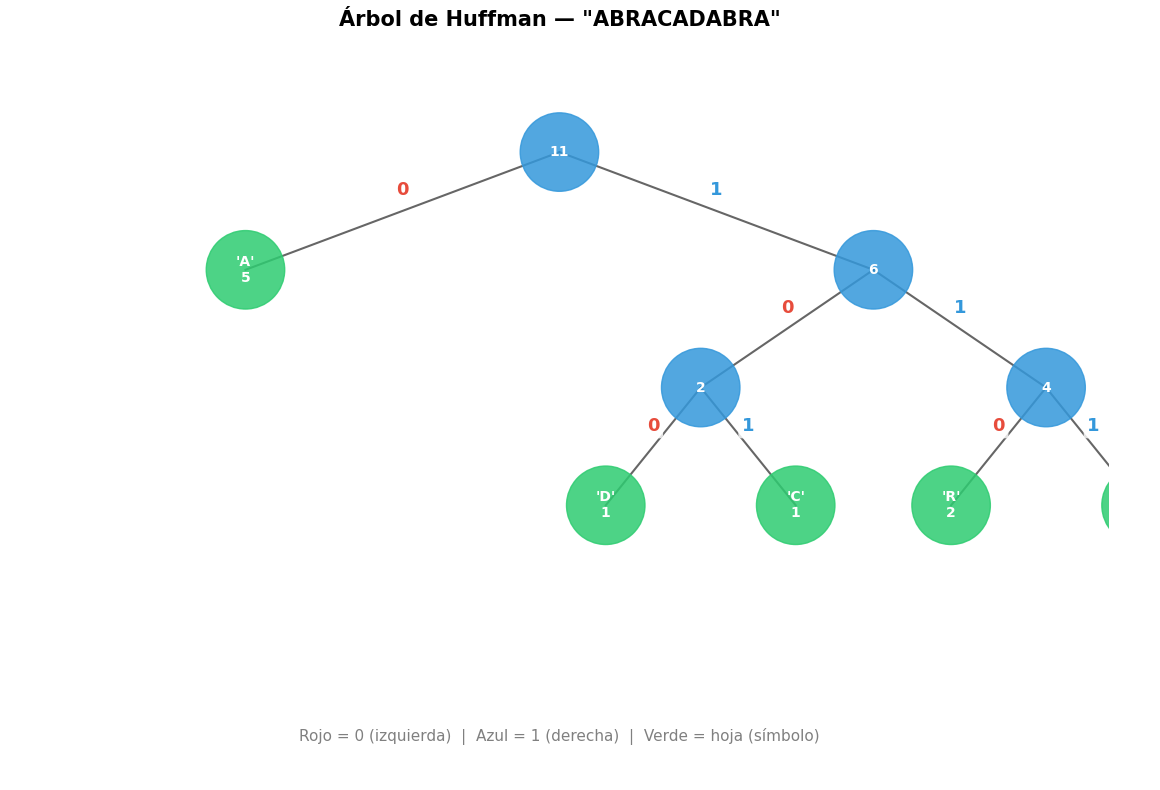

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_huffman_tree(root, text_title="ABRACADABRA"):
    '''Visualize Huffman tree'''
    fig, ax = plt.subplots(figsize=(14, 8))

    # BFS to assign positions
    positions = {}
    labels = {}
    edges = []

    def assign_positions(node, x, y, dx):
        if node is None:
            return
        node_id = id(node)
        positions[node_id] = (x, y)
        if node.char:
            labels[node_id] = f"'{node.char}'\n{node.freq}"
        else:
            labels[node_id] = str(node.freq)

        if node.left:
            edges.append((node_id, id(node.left), '0'))
            assign_positions(node.left, x - dx, y - 1.5, dx * 0.55)
        if node.right:
            edges.append((node_id, id(node.right), '1'))
            assign_positions(node.right, x + dx, y - 1.5, dx * 0.55)

    assign_positions(root, 0, 0, 4)

    # Draw edges
    for parent_id, child_id, bit in edges:
        px, py = positions[parent_id]
        cx, cy = positions[child_id]
        ax.plot([px, cx], [py, cy], 'k-', linewidth=1.5, alpha=0.6, zorder=1)
        mx, my = (px + cx) / 2, (py + cy) / 2
        ax.text(mx, my + 0.2, bit, fontsize=13, ha='center', fontweight='bold',
                color='#E74C3C' if bit == '0' else '#3498DB',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

    # Draw nodes
    for node_id, (x, y) in positions.items():
        is_leaf = "'" in labels[node_id]
        color = '#2ECC71' if is_leaf else '#3498DB'
        radius = 0.5
        circle = plt.Circle((x, y), radius, color=color, alpha=0.85, zorder=2)
        ax.add_patch(circle)
        ax.text(x, y, labels[node_id], ha='center', va='center', fontsize=10,
                fontweight='bold', color='white', zorder=3)

    ax.set_xlim(-7, 7)
    ax.set_ylim(-8, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Árbol de Huffman — "{text_title}"', fontsize=15, fontweight='bold')

    # Legend
    legend_text = "Rojo = 0 (izquierda)  |  Azul = 1 (derecha)  |  Verde = hoja (símbolo)"
    ax.text(0, -7.5, legend_text, ha='center', fontsize=11, color='gray')

    plt.tight_layout()
    plt.show()

plot_huffman_tree(root)

### Animación: Construcción del árbol de Huffman

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import heapq
from collections import Counter

def huffman_build_frames(text):
    '''Generate animation frames for Huffman tree construction'''
    freq = Counter(text)
    # Each frame: list of (label, freq) in the heap
    frames = []

    items = sorted([(f, ch) for ch, f in freq.items()])
    heap = [(f, i, ch) for i, (f, ch) in enumerate(items)]
    heapq.heapify(heap)
    counter = len(heap)

    frames.append({
        'heap': [(f, label) for f, _, label in sorted(heap)],
        'msg': 'Cola de prioridad inicial',
        'merged': None
    })

    while len(heap) > 1:
        f1, _, l1 = heapq.heappop(heap)
        f2, _, l2 = heapq.heappop(heap)
        new_label = f"[{l1}+{l2}]"
        new_freq = f1 + f2
        heapq.heappush(heap, (new_freq, counter, new_label))
        counter += 1

        frames.append({
            'heap': [(f, label) for f, _, label in sorted(heap)],
            'msg': f"Unir '{l1}'({f1}) + '{l2}'({f2}) = {new_freq}",
            'merged': (l1, f1, l2, f2, new_freq)
        })

    return frames

text = "ABRACADABRA"
hframes = huffman_build_frames(text)

fig, ax = plt.subplots(figsize=(12, 6))

def init():
    ax.clear()
    return []

def update(frame_idx):
    ax.clear()
    f = hframes[frame_idx]
    heap_items = f['heap']
    n = len(heap_items)

    max_freq = max(freq for freq, _ in heap_items) if heap_items else 1

    for i, (freq, label) in enumerate(heap_items):
        color = '#FFA500' if f['merged'] and i == n-1 else 'steelblue'
        bar_height = freq
        ax.bar(i, bar_height, color=color, edgecolor='white', linewidth=2, alpha=0.85, width=0.7)
        ax.text(i, bar_height + 0.2, label, ha='center', va='bottom', fontsize=11, fontweight='bold')
        ax.text(i, bar_height / 2, str(freq), ha='center', va='center', fontsize=14,
                fontweight='bold', color='white')

    ax.set_xlim(-0.5, max(7, n) - 0.5)
    ax.set_ylim(0, 14)
    ax.set_xlabel('Elementos en la cola', fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    ax.set_title('Construcción del árbol de Huffman', fontsize=14, fontweight='bold')

    ax.text(0.5, 0.95, f['msg'], transform=ax.transAxes, fontsize=13, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    ax.text(0.5, 0.02, f'Paso {frame_idx}/{len(hframes)-1} — Elementos en cola: {n}',
            transform=ax.transAxes, fontsize=11, ha='center', va='bottom', color='gray')
    return []

anim = FuncAnimation(fig, update, init_func=init, frames=len(hframes), interval=1500, blit=False)
plt.close()
HTML(anim.to_jshtml())

## Lempel-Ziv-Welch (LZW)

### ¿Cómo funciona?

LZW es un algoritmo de compresión basado en **diccionario**. Construye dinámicamente un diccionario de patrones mientras comprime.

### Algoritmo de compresión

```
función LZW_Comprimir(texto):
    diccionario = {cada carácter: su código ASCII}
    siguiente_código = 256
    w = ""
    resultado = []

    para cada carácter c en texto:
        wc = w + c
        si wc está en diccionario:
            w = wc              # extender patrón actual
        sino:
            resultado.agregar(diccionario[w])  # emitir código de w
            diccionario[wc] = siguiente_código  # agregar wc al diccionario
            siguiente_código += 1
            w = c               # reiniciar con c
    resultado.agregar(diccionario[w])  # emitir último patrón
    retornar resultado
```

### Propiedades

- **Sin necesidad de enviar el diccionario**: se reconstruye durante la descompresión
- **Adaptativo**: el diccionario crece con los datos
- **Usado en**: GIF, TIFF, Unix compress

### Complejidad

| Operación | Tiempo | Espacio |
|-----------|--------|---------|
| Comprimir | $O(n)$ | $O(n)$ (diccionario) |
| Descomprimir | $O(n)$ | $O(n)$ (diccionario) |

### Ejemplo paso a paso

**Texto**: `ABABABABAB`

**Diccionario inicial**: `{A: 65, B: 66}` (ASCII)

| Paso | w | c | wc | ¿wc en dict? | Emitir | Agregar al dict |
|------|---|---|----|-------------|--------|-----------------|
| 1 | `""` | `A` | `A` | Sí | — | — |
| 2 | `A` | `B` | `AB` | No | **65** (A) | `AB`: 256 |
| 3 | `B` | `A` | `BA` | No | **66** (B) | `BA`: 257 |
| 4 | `A` | `B` | `AB` | Sí | — | — |
| 5 | `AB` | `A` | `ABA` | No | **256** (AB) | `ABA`: 258 |
| 6 | `A` | `B` | `AB` | Sí | — | — |
| 7 | `AB` | `A` | `ABA` | Sí | — | — |
| 8 | `ABA` | `B` | `ABAB` | No | **258** (ABA) | `ABAB`: 259 |
| 9 | `B` | — | — | fin | **66** (B) | — |

**Resultado**: `[65, 66, 256, 258, 66]` → 5 códigos

- **Original**: 10 caracteres × 8 bits = 80 bits
- **LZW**: 5 códigos × 9 bits = 45 bits (necesitamos ≥9 bits para códigos > 255)
- **Ratio**: 1.78x

In [8]:
def lzw_compress(text):
    '''LZW compression with step trace'''
    # Initialize dictionary with single characters
    dict_size = 256
    dictionary = {chr(i): i for i in range(dict_size)}

    w = ""
    result = []
    steps = []

    for i, c in enumerate(text):
        wc = w + c
        if wc in dictionary:
            steps.append({
                'step': i+1, 'w': w, 'c': c, 'wc': wc,
                'in_dict': True, 'emitted': None, 'added': None
            })
            w = wc
        else:
            result.append(dictionary[w])
            dictionary[wc] = dict_size
            steps.append({
                'step': i+1, 'w': w, 'c': c, 'wc': wc,
                'in_dict': False, 'emitted': (w, dictionary[w] if w != wc else dict_size - 1),
                'added': (wc, dict_size)
            })
            dict_size += 1
            w = c

    if w:
        result.append(dictionary[w])
        steps.append({
            'step': len(text)+1, 'w': w, 'c': '', 'wc': '',
            'in_dict': False, 'emitted': (w, dictionary[w]),
            'added': None
        })

    return result, steps, dictionary

def lzw_decompress(codes):
    '''LZW decompression'''
    dict_size = 256
    dictionary = {i: chr(i) for i in range(dict_size)}

    result = [dictionary[codes[0]]]
    w = result[0]

    for code in codes[1:]:
        if code in dictionary:
            entry = dictionary[code]
        elif code == dict_size:
            entry = w + w[0]
        else:
            raise ValueError(f"Bad code: {code}")

        result.append(entry)
        dictionary[dict_size] = w + entry[0]
        dict_size += 1
        w = entry

    return ''.join(result)

# Demo
text = "ABABABABAB"
codes, steps, final_dict = lzw_compress(text)
decoded = lzw_decompress(codes)

print(f"Texto: '{text}'")
print(f"\nPasos de compresión:")
print(f"{'Paso':>4} | {'w':>5} | {'c':>3} | {'wc':>5} | {'¿En dict?':>9} | {'Emitir':>12} | {'Agregar':>15}")
print("-" * 75)
for s in steps:
    in_d = "Sí" if s['in_dict'] else "No"
    emit = f"{s['emitted'][0]}={s['emitted'][1]}" if s['emitted'] else "—"
    added = f"'{s['added'][0]}':{s['added'][1]}" if s['added'] else "—"
    print(f"{s['step']:>4} | {s['w']:>5} | {s['c']:>3} | {s['wc']:>5} | {in_d:>9} | {emit:>12} | {added:>15}")

print(f"\nCódigos: {codes}")
print(f"Decodificado: '{decoded}'")
print(f"¿Correcto? {decoded == text}")

import math
bits_per_code = max(9, math.ceil(math.log2(max(codes) + 1)))
orig_bits = len(text) * 8
comp_bits = len(codes) * bits_per_code
print(f"\nOriginal: {orig_bits} bits | LZW: {comp_bits} bits ({bits_per_code} bits/código)")
print(f"Ratio: {orig_bits/comp_bits:.2f}x | Ahorro: {(1 - comp_bits/orig_bits)*100:.1f}%")

Texto: 'ABABABABAB'

Pasos de compresión:
Paso |     w |   c |    wc | ¿En dict? |       Emitir |         Agregar
---------------------------------------------------------------------------
   1 |       |   A |     A |        Sí |            — |               —
   2 |     A |   B |    AB |        No |         A=65 |        'AB':256
   3 |     B |   A |    BA |        No |         B=66 |        'BA':257
   4 |     A |   B |    AB |        Sí |            — |               —
   5 |    AB |   A |   ABA |        No |       AB=256 |       'ABA':258
   6 |     A |   B |    AB |        Sí |            — |               —
   7 |    AB |   A |   ABA |        Sí |            — |               —
   8 |   ABA |   B |  ABAB |        No |      ABA=258 |      'ABAB':259
   9 |     B |   A |    BA |        Sí |            — |               —
  10 |    BA |   B |   BAB |        No |       BA=257 |       'BAB':260
  11 |     B |     |       |        No |         B=66 |               —

Códigos: [65, 66,

### Animación: Compresión LZW

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

text_lzw = "TOBEORNOTTOBEORTOBEORNOT"
codes_lzw, steps_lzw, _ = lzw_compress(text_lzw)

# Build frames
anim_frames = []
emitted_so_far = []
dict_entries = []

anim_frames.append({
    'pos': -1, 'w': '', 'msg': 'Inicio',
    'emitted': [], 'dict_new': [], 'highlight': set()
})

for s in steps_lzw:
    if s['emitted']:
        emitted_so_far = emitted_so_far + [s['emitted']]
    if s['added']:
        dict_entries = dict_entries + [s['added']]

    highlight = set()
    if s['w']:
        # find position
        pass

    anim_frames.append({
        'pos': s['step'] - 1,
        'w': s['wc'] if s['in_dict'] else s['c'],
        'msg': f"w='{s['w']}' + c='{s['c']}' → wc='{s['wc']}'" + (" ✓ en dict" if s['in_dict'] else f" ✗ → emitir {s['emitted'][0] if s['emitted'] else ''}"),
        'emitted': list(emitted_so_far),
        'dict_new': list(dict_entries),
        'highlight': set()
    })

fig, ax = plt.subplots(figsize=(14, 7))

def init():
    ax.clear()
    return []

def update(frame_idx):
    ax.clear()
    f = anim_frames[frame_idx]
    n = len(text_lzw)

    # Draw text
    for i, ch in enumerate(text_lzw):
        if i <= f['pos']:
            color = '#2ECC71'
        elif i == f['pos'] + 1:
            color = '#FFA500'
        else:
            color = '#BDC3C7'
        ax.add_patch(plt.Rectangle((i * 0.8, 4), 0.7, 0.7, facecolor=color,
                     edgecolor='white', linewidth=1.5, alpha=0.85))
        ax.text(i * 0.8 + 0.35, 4.35, ch, ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    # Draw emitted codes
    emitted = f['emitted']
    for i, (pattern, code) in enumerate(emitted[-10:]):  # show last 10
        color = '#3498DB' if i < len(emitted) - 1 else '#FFA500'
        ax.add_patch(plt.Rectangle((i * 1.5, 2), 1.3, 0.7, facecolor=color,
                     edgecolor='white', linewidth=1.5, alpha=0.8))
        ax.text(i * 1.5 + 0.65, 2.35, f"{code}", ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        ax.text(i * 1.5 + 0.65, 1.5, f"'{pattern}'", ha='center', va='center', fontsize=8, color='gray')

    # Draw new dictionary entries
    new_entries = f['dict_new']
    for i, (pattern, code) in enumerate(new_entries[-8:]):  # show last 8
        ax.text(i * 2.3, 0.3, f"'{pattern}'→{code}", fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#D5F5E3', edgecolor='#2ECC71', alpha=0.8))

    # Labels
    ax.text(-0.5, 4.35, 'Texto:', fontsize=12, fontweight='bold', va='center')
    ax.text(-0.5, 2.35, 'Códigos:', fontsize=12, fontweight='bold', va='center')
    ax.text(-0.5, 0.3, 'Dict:', fontsize=12, fontweight='bold', va='center')

    # Status
    ax.text(n * 0.4, 5.3, f['msg'], ha='center', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    ax.set_xlim(-1.5, n * 0.8 + 1)
    ax.set_ylim(-0.5, 6)
    ax.axis('off')
    ax.set_title(f'Compresión LZW — Paso {frame_idx}/{len(anim_frames)-1}', fontsize=14, fontweight='bold')
    return []

anim = FuncAnimation(fig, update, init_func=init, frames=len(anim_frames), interval=1000, blit=False)
plt.close()
HTML(anim.to_jshtml())

## Codificación Shannon-Fano

### ¿Cómo funciona?

Shannon-Fano divide los símbolos recursivamente en dos grupos de **frecuencia similar**, asignando `0` a un grupo y `1` al otro.

### Algoritmo

```
función Shannon_Fano(símbolos_ordenados):
    si solo hay 1 símbolo:
        asignar código acumulado
        retornar

    Encontrar el punto de división que minimice
    la diferencia de frecuencias entre los dos grupos

    Grupo izquierdo → agregar '0' al código
    Grupo derecho → agregar '1' al código

    Shannon_Fano(Grupo izquierdo)
    Shannon_Fano(Grupo derecho)
```

### Diferencias con Huffman

| Propiedad | Shannon-Fano | Huffman |
|-----------|-------------|---------|
| Enfoque | Top-down (divide) | Bottom-up (une) |
| Optimalidad | Subóptimo | Óptimo |
| Complejidad | $O(n \log n)$ | $O(n \log n)$ |
| Resultado | Puede dar más bits | Siempre mínimo |

> Shannon-Fano fue históricamente el primero, pero Huffman lo mejoró.

In [10]:
from collections import Counter

def shannon_fano(symbols_freq, prefix="", codes=None):
    '''Shannon-Fano encoding'''
    if codes is None:
        codes = {}

    if len(symbols_freq) == 1:
        codes[symbols_freq[0][0]] = prefix if prefix else "0"
        return codes

    if len(symbols_freq) == 2:
        codes[symbols_freq[0][0]] = prefix + "0"
        codes[symbols_freq[1][0]] = prefix + "1"
        return codes

    # Find split point that minimizes frequency difference
    total = sum(f for _, f in symbols_freq)
    best_diff = float('inf')
    best_split = 1
    running = 0
    for i in range(len(symbols_freq) - 1):
        running += symbols_freq[i][1]
        diff = abs(2 * running - total)
        if diff < best_diff:
            best_diff = diff
            best_split = i + 1

    shannon_fano(symbols_freq[:best_split], prefix + "0", codes)
    shannon_fano(symbols_freq[best_split:], prefix + "1", codes)
    return codes

# Compare Shannon-Fano vs Huffman
text = "ABRACADABRA"
freq = Counter(text)
sorted_freq = sorted(freq.items(), key=lambda x: -x[1])

sf_codes = shannon_fano(sorted_freq)
root, _, _ = build_huffman_tree(text)
huff_codes = get_codes(root)

print(f"Texto: '{text}'")
print(f"\n{'Símbolo':>8} | {'Freq':>5} | {'Shannon-Fano':>13} | {'Huffman':>10}")
print("-" * 50)
for ch, f in sorted_freq:
    print(f"    '{ch}'  |   {f:>3} | {sf_codes[ch]:>13} | {huff_codes[ch]:>10}")

sf_bits = sum(len(sf_codes[ch]) * freq[ch] for ch in freq)
hf_bits = sum(len(huff_codes[ch]) * freq[ch] for ch in freq)
entropy = -sum((f/len(text)) * np.log2(f/len(text)) for f in freq.values())

print(f"\nTotal bits Shannon-Fano: {sf_bits}")
print(f"Total bits Huffman:     {hf_bits}")
print(f"Entropía × n:           {entropy * len(text):.1f}")
print(f"\nHuffman ahorra {sf_bits - hf_bits} bits sobre Shannon-Fano")

Texto: 'ABRACADABRA'

 Símbolo |  Freq |  Shannon-Fano |    Huffman
--------------------------------------------------
    'A'  |     5 |             0 |          0
    'B'  |     2 |            10 |        111
    'R'  |     2 |           110 |        110
    'C'  |     1 |          1110 |        101
    'D'  |     1 |          1111 |        100

Total bits Shannon-Fano: 23
Total bits Huffman:     23
Entropía × n:           22.4

Huffman ahorra 0 bits sobre Shannon-Fano


## LZ77 (Lempel-Ziv 1977)

### ¿Cómo funciona?

LZ77 usa una **ventana deslizante** para encontrar coincidencias previas del texto actual. Emite tripletas `(distancia, longitud, siguiente_carácter)`.

### Algoritmo

```
función LZ77_Comprimir(texto, ventana):
    posición = 0
    resultado = []

    mientras posición < longitud(texto):
        mejor_distancia = 0
        mejor_longitud = 0

        para cada posición previa p en la ventana:
            longitud_match = coincidencia(texto, p, posición)
            si longitud_match > mejor_longitud:
                mejor_distancia = posición - p
                mejor_longitud = longitud_match

        siguiente = texto[posición + mejor_longitud]
        resultado.agregar( (mejor_distancia, mejor_longitud, siguiente) )
        posición += mejor_longitud + 1

    retornar resultado
```

### Propiedades

- **Base de**: gzip, DEFLATE (ZIP, PNG), 7z, zstd
- **Ventana deslizante**: típicamente 32KB
- DEFLATE = LZ77 + Huffman

### Complejidad

| Operación | Tiempo | Espacio |
|-----------|--------|---------|
| Comprimir | $O(n \cdot w)$ | $O(w)$ |
| Descomprimir | $O(n)$ | $O(w)$ |

donde $w$ = tamaño de la ventana.

### Ejemplo paso a paso

**Texto**: `AABABCABABC`
**Ventana**: tamaño 7

| Paso | Pos | Ventana (búsqueda) | Match | Tripleta | Significado |
|------|-----|--------------------|-------|----------|-------------|
| 1 | 0 | `""` | ninguno | `(0, 0, 'A')` | Literal 'A' |
| 2 | 1 | `"A"` | `A` en pos 0 | `(1, 1, 'B')` | Copiar 1 desde dist 1 + 'B' |
| 3 | 3 | `"AAB"` | `AB` en pos 1 | `(2, 2, 'C')` | Copiar 2 desde dist 2 + 'C' |
| 4 | 6 | `"AABABC"` | `ABABC` en pos 1 | `(5, 5, '')` | Copiar 5 desde dist 5 |

**Resultado**: `[(0,0,'A'), (1,1,'B'), (2,2,'C'), (5,5,'')]`

In [11]:
def lz77_compress(text, window_size=20):
    '''LZ77 compression with step trace'''
    result = []
    steps = []
    i = 0

    while i < len(text):
        best_dist = 0
        best_length = 0

        # Search in the window
        start = max(0, i - window_size)
        for j in range(start, i):
            length = 0
            while (i + length < len(text) and
                   length < window_size and
                   text[j + length] == text[i + length]):
                length += 1
            if length > best_length:
                best_length = length
                best_dist = i - j

        next_char = text[i + best_length] if i + best_length < len(text) else ''
        result.append((best_dist, best_length, next_char))

        window_view = text[max(0, i - window_size):i]
        lookahead = text[i:i + best_length + 1]
        steps.append({
            'pos': i,
            'window': window_view,
            'lookahead': lookahead,
            'dist': best_dist,
            'length': best_length,
            'next': next_char,
            'match': text[i:i+best_length] if best_length > 0 else ''
        })

        i += best_length + 1

    return result, steps

def lz77_decompress(tokens):
    '''LZ77 decompression'''
    result = []
    for dist, length, char in tokens:
        if length > 0:
            start = len(result) - dist
            for j in range(length):
                result.append(result[start + j])
        if char:
            result.append(char)
    return ''.join(result)

# Demo
text = "AABABCABABCABABC"
tokens, steps = lz77_compress(text, window_size=10)
decoded = lz77_decompress(tokens)

print(f"Texto: '{text}' ({len(text)} chars)")
print(f"\nPasos de compresión:")
print(f"{'Paso':>4} | {'Pos':>3} | {'Ventana':>12} | {'Match':>8} | {'Tripleta':>18}")
print("-" * 65)
for i, s in enumerate(steps):
    triple = f"({s['dist']}, {s['length']}, '{s['next']}')"
    match = f"'{s['match']}'" if s['match'] else "—"
    print(f"{i+1:>4} | {s['pos']:>3} | {s['window']:>12} | {match:>8} | {triple:>18}")

print(f"\nTokens: {tokens}")
print(f"Decodificado: '{decoded}'")
print(f"¿Correcto? {decoded == text}")

orig_bits = len(text) * 8
# Each token: ~log2(window) + log2(window) + 8 bits
token_bits = len(tokens) * (4 + 4 + 8)  # simplified
print(f"\nOriginal: {orig_bits} bits | LZ77 (aprox): {token_bits} bits")
print(f"Tokens emitidos: {len(tokens)} (vs {len(text)} caracteres)")

Texto: 'AABABCABABCABABC' (16 chars)

Pasos de compresión:
Paso | Pos |      Ventana |    Match |           Tripleta
-----------------------------------------------------------------
   1 |   0 |              |        — |        (0, 0, 'A')
   2 |   1 |            A |      'A' |        (1, 1, 'B')
   3 |   3 |          AAB |     'AB' |        (2, 2, 'C')
   4 |   6 |       AABABC | 'ABABCABABC' |        (5, 10, '')

Tokens: [(0, 0, 'A'), (1, 1, 'B'), (2, 2, 'C'), (5, 10, '')]
Decodificado: 'AABABCABABCABABC'
¿Correcto? True

Original: 128 bits | LZ77 (aprox): 64 bits
Tokens emitidos: 4 (vs 16 caracteres)


### Animación: Compresión LZ77 con ventana deslizante

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

text_lz = "AABABCABABCABABC"
tokens_lz, steps_lz = lz77_compress(text_lz, window_size=10)

fig, ax = plt.subplots(figsize=(14, 6))

# Build frames: one per step
anim_data = []
anim_data.append({'step': 0, 'pos': 0, 'dist': 0, 'length': 0, 'next': '', 'match_start': -1,
                   'msg': 'Inicio — ventana vacía', 'tokens_so_far': []})

tokens_accum = []
for i, s in enumerate(steps_lz):
    tokens_accum = tokens_accum + [(s['dist'], s['length'], s['next'])]
    match_start = s['pos'] - s['dist'] if s['dist'] > 0 else -1
    if s['dist'] > 0:
        msg = f"Match! Copiar {s['length']} chars desde dist {s['dist']}"
        if s['next']:
            msg += f" + '{s['next']}'"
    else:
        msg = f"Sin match → literal '{s['next']}'"
    anim_data.append({
        'step': i + 1, 'pos': s['pos'], 'dist': s['dist'],
        'length': s['length'], 'next': s['next'],
        'match_start': match_start,
        'msg': msg,
        'tokens_so_far': list(tokens_accum)
    })

def init():
    ax.clear()
    return []

def update(frame_idx):
    ax.clear()
    f = anim_data[frame_idx]
    n = len(text_lz)

    # Draw characters
    for i, ch in enumerate(text_lz):
        if f['match_start'] >= 0 and f['match_start'] <= i < f['match_start'] + f['length']:
            color = '#3498DB'  # match source
        elif f['pos'] <= i < f['pos'] + f['length']:
            color = '#FFA500'  # current match
        elif i == f['pos'] + f['length'] and f['next'] and i < n:
            color = '#E74C3C'  # next char
        elif i < f['pos']:
            color = '#2ECC71'  # processed
        else:
            color = '#BDC3C7'  # unprocessed

        ax.add_patch(plt.Rectangle((i, 2.5), 0.9, 0.9, facecolor=color,
                     edgecolor='white', linewidth=2, alpha=0.85))
        ax.text(i + 0.45, 2.95, ch, ha='center', va='center', fontsize=13, fontweight='bold', color='white')
        ax.text(i + 0.45, 2.1, str(i), ha='center', fontsize=8, color='gray')

    # Draw arrow for match
    if f['match_start'] >= 0 and f['length'] > 0:
        src_x = f['match_start'] + f['length'] / 2
        dst_x = f['pos'] + f['length'] / 2
        ax.annotate('', xy=(dst_x, 2.5), xytext=(src_x, 2.5),
                    arrowprops=dict(arrowstyle='->', color='#3498DB', lw=2.5))

    # Draw tokens
    tokens = f['tokens_so_far']
    for i, (d, l, c) in enumerate(tokens[-8:]):
        token_str = f"({d},{l},'{c}')"
        color = '#2ECC71' if i < len(tokens) - 1 else '#FFA500'
        ax.text(i * 2.2, 1, token_str, fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='white', alpha=0.8),
                color='white')

    ax.text(-0.5, 1, 'Tokens:', fontsize=11, fontweight='bold', va='center')

    # Status
    ax.text(n/2, 4.2, f['msg'], ha='center', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # Legend
    ax.text(n/2, 0.1,
            '🟢 Procesado  🟠 Match actual  🔵 Fuente del match  🔴 Siguiente char',
            ha='center', fontsize=9, color='gray')

    ax.set_xlim(-1.5, n + 1)
    ax.set_ylim(-0.3, 5)
    ax.axis('off')
    ax.set_title(f'Compresión LZ77 — Paso {f["step"]}/{len(steps_lz)}', fontsize=14, fontweight='bold')
    return []

anim = FuncAnimation(fig, update, init_func=init, frames=len(anim_data), interval=1500, blit=False)
plt.close()
HTML(anim.to_jshtml())

/tmp/ipykernel_828/2504884467.py:96: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_828/2504884467.py:96: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_828/2504884467.py:96: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_828/2504884467.py:96: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())


## Codificación Aritmética (concepto)

### ¿Cómo funciona?

A diferencia de Huffman (que asigna un código entero de bits a cada símbolo), la codificación aritmética representa **todo el mensaje** como un único número en el intervalo $[0, 1)$.

### Algoritmo

```
función Aritmética_Comprimir(texto, probabilidades):
    lo = 0.0
    hi = 1.0

    para cada símbolo s en texto:
        rango = hi - lo
        hi = lo + rango × límite_superior(s)
        lo = lo + rango × límite_inferior(s)

    retornar cualquier número en [lo, hi)
```

### Ejemplo

**Texto**: `ABC`
**Probabilidades**: A=0.5, B=0.3, C=0.2
**Rangos**: A=[0, 0.5), B=[0.5, 0.8), C=[0.8, 1.0)

| Paso | Símbolo | Intervalo |
|------|---------|-----------|
| Inicio | — | $[0.0, 1.0)$ |
| A | A → [0, 0.5) | $[0.0, 0.5)$ |
| B | B → [0.5, 0.8) | $[0.25, 0.4)$ |
| C | C → [0.8, 1.0) | $[0.37, 0.4)$ |

**Resultado**: cualquier número en $[0.37, 0.4)$, por ejemplo $0.38$

### Ventajas sobre Huffman

- Puede acercarse **más** a la entropía (Huffman solo usa bits enteros por símbolo)
- Especialmente mejor cuando un símbolo tiene probabilidad > 0.5
- **Usado en**: JPEG 2000, H.264, H.265, LZMA/7z

Texto: 'ABCAB'
Probabilidades: {'A': 0.5, 'B': 0.3, 'C': 0.2}

Rangos base: A=[0.0, 0.5), B=[0.5, 0.8), C=[0.8, 1.0)

Paso |  Símbolo |                      Intervalo
--------------------------------------------------
   0 |          | [0.00000000, 1.00000000)
   1 |        A | [0.00000000, 0.50000000)
   2 |        B | [0.25000000, 0.40000000)
   3 |        C | [0.37000000, 0.40000000)
   4 |        A | [0.37000000, 0.38500000)
   5 |        B | [0.37750000, 0.38200000)

Intervalo final: [0.37750000, 0.38200000)
Valor codificado: 0.37975000
Bits necesarios: 9

Entropía: 1.485 bits/símbolo
Bits teóricos: 7.4
Bits aritmética: 9


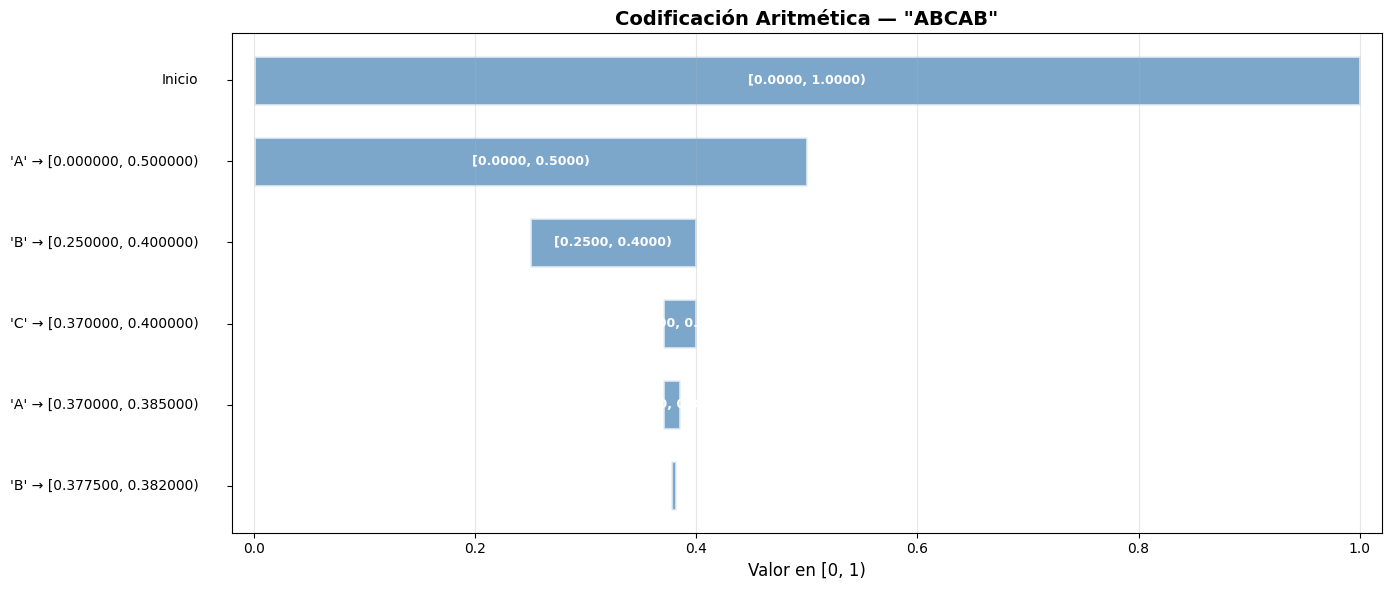

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def arithmetic_encode_visual(text, probs):
    '''Arithmetic encoding with visualization data'''
    # Build cumulative ranges
    symbols = sorted(probs.keys())
    ranges = {}
    cum = 0.0
    for s in symbols:
        ranges[s] = (cum, cum + probs[s])
        cum += probs[s]

    lo, hi = 0.0, 1.0
    history = [{'lo': lo, 'hi': hi, 'symbol': '', 'step': 'Inicio'}]

    for ch in text:
        r = hi - lo
        new_hi = lo + r * ranges[ch][1]
        new_lo = lo + r * ranges[ch][0]
        lo, hi = new_lo, new_hi
        history.append({'lo': lo, 'hi': hi, 'symbol': ch, 'step': f"'{ch}' → [{lo:.6f}, {hi:.6f})"})

    return lo, hi, history, ranges

text_ae = "ABCAB"
probs = {'A': 0.5, 'B': 0.3, 'C': 0.2}
lo, hi, history, ranges = arithmetic_encode_visual(text_ae, probs)

# Print steps
print(f"Texto: '{text_ae}'")
print(f"Probabilidades: {probs}")
print(f"\nRangos base: {', '.join(f'{s}=[{r[0]:.1f}, {r[1]:.1f})' for s, r in ranges.items())}")
print(f"\n{'Paso':>4} | {'Símbolo':>8} | {'Intervalo':>30}")
print("-" * 50)
for h in history:
    print(f"{history.index(h):>4} | {h['symbol']:>8} | [{h['lo']:.8f}, {h['hi']:.8f})")

code_value = (lo + hi) / 2
bits_needed = int(np.ceil(-np.log2(hi - lo))) + 1
print(f"\nIntervalo final: [{lo:.8f}, {hi:.8f})")
print(f"Valor codificado: {code_value:.8f}")
print(f"Bits necesarios: {bits_needed}")

entropy = -sum(p * np.log2(p) for p in probs.values())
print(f"\nEntropía: {entropy:.3f} bits/símbolo")
print(f"Bits teóricos: {entropy * len(text_ae):.1f}")
print(f"Bits aritmética: {bits_needed}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'A': '#3498DB', 'B': '#2ECC71', 'C': '#E67E22'}
n_steps = len(history)

for i, h in enumerate(history):
    x = i
    width = 0.6
    lo_val = h['lo']
    hi_val = h['hi']

    # Draw interval
    ax.barh(i, hi_val - lo_val, left=lo_val, height=0.6, color='steelblue', alpha=0.7, edgecolor='white', linewidth=2)
    # Label
    interval_width = hi_val - lo_val
    if interval_width > 0.01:
        ax.text(lo_val + interval_width/2, i, f"[{lo_val:.4f}, {hi_val:.4f})",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax.text(-0.05, i, h['step'], ha='right', va='center', fontsize=10)

ax.set_xlabel('Valor en [0, 1)', fontsize=12)
ax.set_title(f'Codificación Aritmética — "{text_ae}"', fontsize=14, fontweight='bold')
ax.set_xlim(-0.02, 1.02)
ax.set_yticks(range(n_steps))
ax.set_yticklabels(['' for _ in range(n_steps)])
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Comparación de algoritmos

| Algoritmo | Tipo | Compresión | Descompresión | Mejor para |
|-----------|------|------------|---------------|------------|
| **RLE** | Sin pérdida | $O(n)$ | $O(n)$ | Datos con muchas repeticiones |
| **Huffman** | Sin pérdida | $O(n \log n)$ | $O(n)$ | Texto, datos generales |
| **Shannon-Fano** | Sin pérdida | $O(n \log n)$ | $O(n)$ | Similar a Huffman (subóptimo) |
| **LZW** | Sin pérdida | $O(n)$ | $O(n)$ | Texto con patrones repetidos |
| **LZ77** | Sin pérdida | $O(n \cdot w)$ | $O(n)$ | Datos generales (base de gzip/zip) |
| **Aritmético** | Sin pérdida | $O(n)$ | $O(n)$ | Distribuciones muy sesgadas |

### ¿Cuál usar?

- **Datos con repeticiones simples** → RLE (rápido y simple)
- **Texto general** → Huffman o LZW
- **Archivos grandes** → LZ77 + Huffman (DEFLATE/gzip)
- **Máxima compresión** → Aritmético + LZ (LZMA/7z)
- **Imágenes** → PNG (DEFLATE), JPEG (DCT + Huffman/Aritmético)
- **Video** → H.264/H.265 (predicción + aritmético)

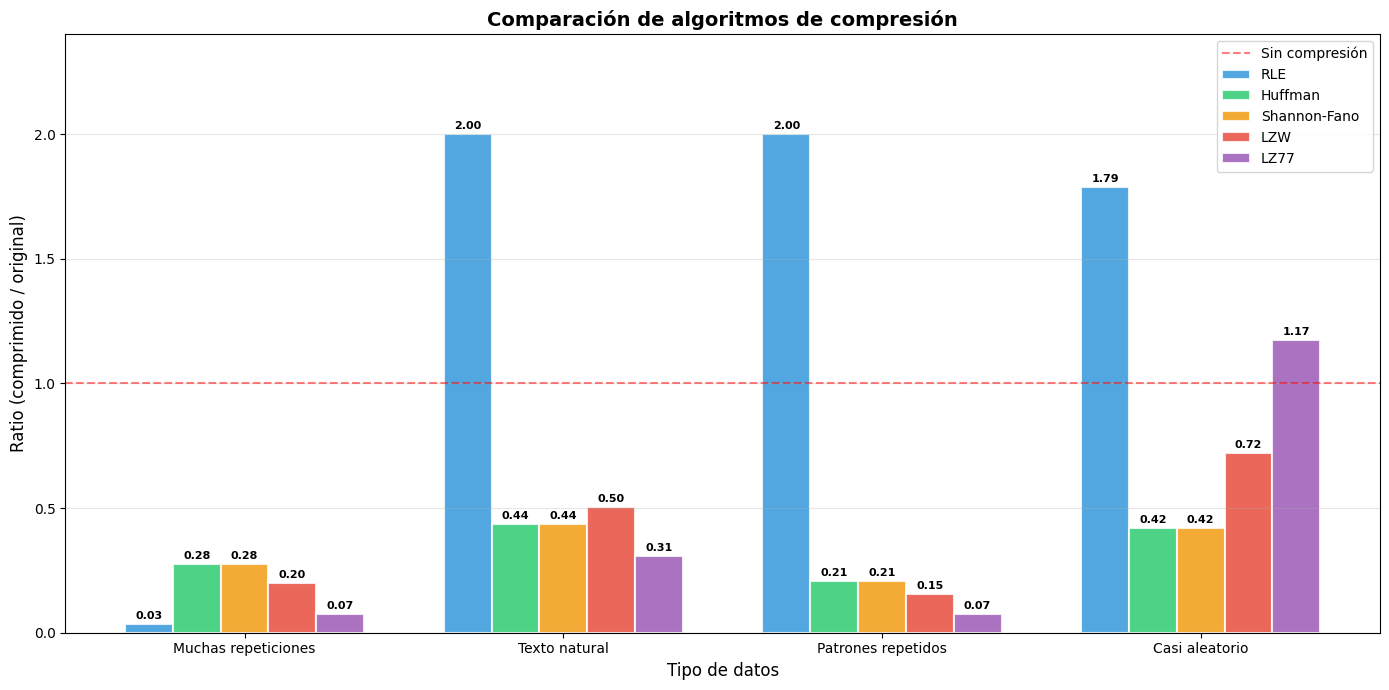

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Compare all algorithms on the same text
test_texts = {
    'Muchas repeticiones': 'A' * 100 + 'B' * 80 + 'C' * 60 + 'D' * 40 + 'E' * 20,
    'Texto natural': 'to be or not to be that is the question whether tis nobler ' * 5,
    'Patrones repetidos': 'ABCABC' * 50,
    'Casi aleatorio': ''.join(np.random.choice(list('ABCDEFGHIJ'), 300)),
}

results = {name: {} for name in test_texts}

for name, text in test_texts.items():
    orig_bits = len(text) * 8

    # RLE
    enc_rle, _ = rle_encode(text)
    rle_bits = 2 * len(enc_rle) * 8  # symbol + count as chars
    results[name]['RLE'] = rle_bits / orig_bits

    # Huffman
    root_h, _, freq_h = build_huffman_tree(text)
    codes_h = get_codes(root_h)
    huff_encoded = huffman_encode(text, codes_h)
    huff_bits = len(huff_encoded)
    results[name]['Huffman'] = huff_bits / orig_bits

    # LZW
    codes_lzw_r, _, _ = lzw_compress(text)
    import math
    bpc = max(9, math.ceil(math.log2(max(max(codes_lzw_r) + 1, 2))))
    lzw_bits = len(codes_lzw_r) * bpc
    results[name]['LZW'] = lzw_bits / orig_bits

    # LZ77
    tokens_lz77, _ = lz77_compress(text, window_size=64)
    lz77_bits = len(tokens_lz77) * (7 + 7 + 8)  # dist + len + char
    results[name]['LZ77'] = lz77_bits / orig_bits

    # Shannon-Fano
    freq_sf = Counter(text)
    sorted_sf = sorted(freq_sf.items(), key=lambda x: -x[1])
    sf_codes_r = shannon_fano(sorted_sf)
    sf_bits = sum(len(sf_codes_r[ch]) * freq_sf[ch] for ch in freq_sf)
    results[name]['Shannon-Fano'] = sf_bits / orig_bits

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

algorithms = ['RLE', 'Huffman', 'Shannon-Fano', 'LZW', 'LZ77']
x = np.arange(len(test_texts))
width = 0.15
colors = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6']

for i, alg in enumerate(algorithms):
    vals = [results[name][alg] for name in test_texts]
    bars = ax.bar(x + i * width, vals, width, label=alg, color=colors[i], alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Sin compresión')
ax.set_xlabel('Tipo de datos', fontsize=12)
ax.set_ylabel('Ratio (comprimido / original)', fontsize=12)
ax.set_title('Comparación de algoritmos de compresión', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(test_texts.keys(), fontsize=10)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, max(max(results[n][a] for a in algorithms) for n in test_texts) * 1.2)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Implementaciones completas

In [15]:
import numpy as np
import heapq
from collections import Counter
import math

# ==================== RLE ====================
def rle_encode(text):
    '''Run-Length Encoding compression'''
    if not text: return []
    encoded = []
    i = 0
    while i < len(text):
        char = text[i]
        count = 1
        while i + count < len(text) and text[i + count] == char:
            count += 1
        encoded.append((char, count))
        i += count
    return encoded

def rle_decode(encoded):
    '''Run-Length Encoding decompression'''
    return ''.join(char * count for char, count in encoded)

# ==================== HUFFMAN ====================
class HuffmanNode:
    def __init__(self, char=None, freq=0, left=None, right=None):
        self.char, self.freq, self.left, self.right = char, freq, left, right
    def __lt__(self, other):
        return self.freq < other.freq

def huffman_build(text):
    '''Build Huffman tree, return (root, codes)'''
    freq = Counter(text)
    heap = [HuffmanNode(char=ch, freq=f) for ch, f in freq.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        l, r = heapq.heappop(heap), heapq.heappop(heap)
        heapq.heappush(heap, HuffmanNode(freq=l.freq+r.freq, left=l, right=r))
    root = heap[0]
    codes = {}
    def traverse(node, prefix=""):
        if node.char is not None:
            codes[node.char] = prefix or "0"
        else:
            if node.left: traverse(node.left, prefix + "0")
            if node.right: traverse(node.right, prefix + "1")
    traverse(root)
    return root, codes

def huffman_encode(text, codes):
    '''Huffman encode text given codes dict'''
    return ''.join(codes[ch] for ch in text)

def huffman_decode(bits, root):
    '''Huffman decode bit string given tree root'''
    result, node = [], root
    for b in bits:
        node = node.left if b == '0' else node.right
        if node.char is not None:
            result.append(node.char)
            node = root
    return ''.join(result)

# ==================== SHANNON-FANO ====================
def shannon_fano_codes(text):
    '''Shannon-Fano encoding, returns codes dict'''
    freq = Counter(text)
    sorted_freq = sorted(freq.items(), key=lambda x: -x[1])
    codes = {}
    def build(symbols, prefix=""):
        if len(symbols) == 1:
            codes[symbols[0][0]] = prefix or "0"
            return
        if len(symbols) == 2:
            codes[symbols[0][0]] = prefix + "0"
            codes[symbols[1][0]] = prefix + "1"
            return
        total = sum(f for _, f in symbols)
        best_split, best_diff, running = 1, float('inf'), 0
        for i in range(len(symbols) - 1):
            running += symbols[i][1]
            diff = abs(2 * running - total)
            if diff < best_diff:
                best_diff, best_split = diff, i + 1
        build(symbols[:best_split], prefix + "0")
        build(symbols[best_split:], prefix + "1")
    build(sorted_freq)
    return codes

# ==================== LZW ====================
def lzw_compress(text):
    '''LZW compression, returns list of integer codes'''
    dictionary = {chr(i): i for i in range(256)}
    dict_size, w, result = 256, "", []
    for c in text:
        wc = w + c
        if wc in dictionary:
            w = wc
        else:
            result.append(dictionary[w])
            dictionary[wc] = dict_size
            dict_size += 1
            w = c
    if w:
        result.append(dictionary[w])
    return result

def lzw_decompress(codes):
    '''LZW decompression'''
    dictionary = {i: chr(i) for i in range(256)}
    dict_size = 256
    result = [dictionary[codes[0]]]
    w = result[0]
    for code in codes[1:]:
        entry = dictionary[code] if code in dictionary else w + w[0]
        result.append(entry)
        dictionary[dict_size] = w + entry[0]
        dict_size += 1
        w = entry
    return ''.join(result)

# ==================== LZ77 ====================
def lz77_compress(text, window_size=4096):
    '''LZ77 compression, returns list of (dist, length, char) tuples'''
    result, i = [], 0
    while i < len(text):
        best_dist = best_len = 0
        for j in range(max(0, i - window_size), i):
            length = 0
            while (i + length < len(text) and length < window_size
                   and text[j + length] == text[i + length]):
                length += 1
            if length > best_len:
                best_dist, best_len = i - j, length
        next_ch = text[i + best_len] if i + best_len < len(text) else ''
        result.append((best_dist, best_len, next_ch))
        i += best_len + 1
    return result

def lz77_decompress(tokens):
    '''LZ77 decompression'''
    result = []
    for dist, length, char in tokens:
        start = len(result) - dist
        for j in range(length):
            result.append(result[start + j])
        if char:
            result.append(char)
    return ''.join(result)

# ==================== DEMO ====================
text = "abracadabra simsalabim"
print(f"Texto: '{text}' ({len(text)} chars, {len(text)*8} bits)\n")

# RLE
enc = rle_encode(text)
print(f"RLE: {len(enc)} runs → '{rle_decode(enc)}'")

# Huffman
root, codes = huffman_build(text)
bits = huffman_encode(text, codes)
print(f"Huffman: {len(bits)} bits → '{huffman_decode(bits, root)}'")

# Shannon-Fano
sf = shannon_fano_codes(text)
sf_bits = ''.join(sf[c] for c in text)
print(f"Shannon-Fano: {len(sf_bits)} bits")

# LZW
lzw_c = lzw_compress(text)
print(f"LZW: {len(lzw_c)} códigos → '{lzw_decompress(lzw_c)}'")

# LZ77
lz_c = lz77_compress(text, window_size=20)
print(f"LZ77: {len(lz_c)} tokens → '{lz77_decompress(lz_c)}'")

Texto: 'abracadabra simsalabim' (22 chars, 176 bits)

RLE: 22 runs → 'abracadabra simsalabim'
Huffman: 67 bits → 'abracadabra simsalabim'
Shannon-Fano: 68 bits
LZW: 18 códigos → 'abracadabra simsalabim'
LZ77: 13 tokens → 'abracadabra simsalabim'


## Entropía y límites teóricos

### Primer Teorema de Shannon (Codificación de Fuente)

Para una fuente con entropía $H$, ningún código sin pérdida puede lograr menos de $H$ bits por símbolo en promedio.

$$L_{avg} \geq H = -\sum_{i} p_i \log_2 p_i$$

### ¿Qué tan cerca están nuestros algoritmos?

La **eficiencia** de un código se mide como:

$$\eta = \frac{H}{L_{avg}} \times 100\%$$

Un código es perfecto si $\eta = 100\%$.

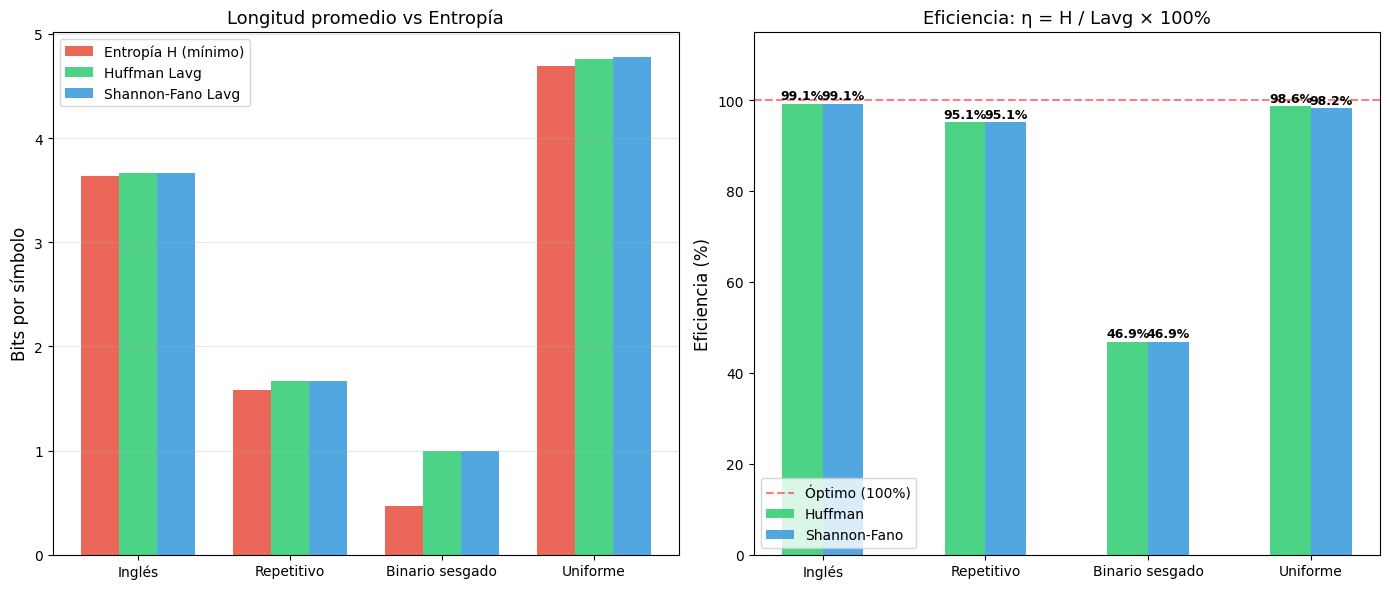

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

texts = {
    'Inglés': 'to be or not to be that is the question whether tis nobler in the mind to suffer',
    'Repetitivo': 'AAABBBCCCAAABBBCCCAAABBBCCC' * 3,
    'Binario sesgado': '0' * 90 + '1' * 10,
    'Uniforme': ''.join(chr(65 + i % 26) for i in range(100)),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names = []
entropies = []
huffman_avgs = []
sf_avgs = []

for name, text in texts.items():
    freq = Counter(text)
    n = len(text)
    # Entropy
    H = -sum((f/n) * np.log2(f/n) for f in freq.values())
    entropies.append(H)

    # Huffman average length
    root_h, codes_h = huffman_build(text)
    avg_huff = sum(len(codes_h[ch]) * freq[ch] for ch in freq) / n
    huffman_avgs.append(avg_huff)

    # Shannon-Fano average length
    sf_c = shannon_fano_codes(text)
    avg_sf = sum(len(sf_c[ch]) * freq[ch] for ch in freq) / n
    sf_avgs.append(avg_sf)

    names.append(name)

x = np.arange(len(names))
width = 0.25

axes[0].bar(x - width, entropies, width, label='Entropía H (mínimo)', color='#E74C3C', alpha=0.85)
axes[0].bar(x, huffman_avgs, width, label='Huffman Lavg', color='#2ECC71', alpha=0.85)
axes[0].bar(x + width, sf_avgs, width, label='Shannon-Fano Lavg', color='#3498DB', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=10)
axes[0].set_ylabel('Bits por símbolo', fontsize=12)
axes[0].set_title('Longitud promedio vs Entropía', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, axis='y', alpha=0.3)

# Efficiency
eff_huff = [H/L * 100 if L > 0 else 0 for H, L in zip(entropies, huffman_avgs)]
eff_sf = [H/L * 100 if L > 0 else 0 for H, L in zip(entropies, sf_avgs)]

axes[1].bar(x - width/2, eff_huff, width, label='Huffman', color='#2ECC71', alpha=0.85)
axes[1].bar(x + width/2, eff_sf, width, label='Shannon-Fano', color='#3498DB', alpha=0.85)
axes[1].axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Óptimo (100%)')
for i, (eh, es) in enumerate(zip(eff_huff, eff_sf)):
    axes[1].text(i - width/2, eh + 1, f'{eh:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + width/2, es + 1, f'{es:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, fontsize=10)
axes[1].set_ylabel('Eficiencia (%)', fontsize=12)
axes[1].set_title('Eficiencia: η = H / Lavg × 100%', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 115)

plt.tight_layout()
plt.show()